结直肠癌数据集
datasets/12_colorectal_cancer_CRC/12_colorectal_cancer_CRC_h5ad/SN048_A121573_Rep1.h5ad
使用修改后的十个四元组训练

===== Cell 1: 基础环境配置与 GPU 绑定 =====

In [1]:
# =========================================================
# Cell 1: 环境配置与模型导入
# =========================================================
import os
import sys
import warnings

# 1. 强制只使用 GPU 0 (必须在 import torch 之前)
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
warnings.filterwarnings("ignore")

import torch
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np
import scipy.sparse as sp
import decoupler as dc
from io import StringIO
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

# 2. 导入原版 NicheCompass
LOCAL_SRC = "/home/zhangjunyi/xiangmu/nichecompass-main/src"
if LOCAL_SRC not in sys.path:
    sys.path.insert(0, LOCAL_SRC)
import nichecompass as nc

print("✅ CUDA 可用状态:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("✅ 当前使用 GPU:", torch.cuda.get_device_name(0))
print("✅ NicheCompass 路径:", nc.__file__)

✅ CUDA 可用状态: True
✅ 当前使用 GPU: A100 80GB PCIe
✅ NicheCompass 路径: /home/zhangjunyi/xiangmu/nichecompass-main/src/nichecompass/__init__.py


===== Cell 2: Step 1 - 构建代谢知识库与加载数据 =====

In [2]:
# =========================================================
# Cell 2: 知识库提取与数据加载 (Step 1)
# =========================================================
print("=== Step 1: 构建代谢通讯轴四元组知识库 ===")

# 1. 解析你的四元组知识库
tmcn_csv = """TMCN_Name,Source_Pathways,Source_Genes,Target_Genes,Biologic_Meaning
TMCN_Lactate_Axis,"Hypoxia,EGFR,PI3K,MAPK","SLC2A1,HK2,PKM,LDHA,LDHB,SLC16A3","SLC16A1,SLC16A7,HCAR1,HCAR2",乳酸_肿瘤酸化瓦伯格效应与基质反向代谢共生
TMCN_Adenosine_Axis,"Hypoxia,TGFb,NFkB,MAPK","ENTPD1,ENTPD2,NT5E,CD38,ENPP1,NT5C2","ADORA1,ADORA2A,ADORA2B,ADORA3,SLC29A1,SLC29A2",腺苷_ATP水解级联驱动的强效免疫抑制与M2极化
TMCN_PGE2_Axis,"NFkB,JAK-STAT,Hypoxia,MAPK,TNFa","PLA2G4A,PTGS2,PTGES,ABCC4,SLCO2A1","PTGER1,PTGER2,PTGER3,PTGER4",前列腺素E2_成纤维细胞激活与促癌炎症微环境重塑
TMCN_Glutamine_Axis,"PI3K,MAPK,JAK-STAT,TGFb,WNT","GLUL,SLC38A1,SLC38A3,SLC38A5","SLC1A5,SLC7A5,SLC38A2,GLS,GLUD1",谷氨酰胺_基质向肿瘤供能的代谢寄生与大分子合成
TMCN_Succinate_Axis,"Hypoxia,NFkB,TNFa","SLC13A2,SLC13A3,SLC25A10","SUCNR1",琥珀酸_缺血坏死区释放驱动的TAM致瘤极化与血管生成
TMCN_Kynurenine_Axis,"JAK-STAT,NFkB,TGFb","IDO1,TDO2,KYNU,SLC7A5","AHR",犬尿氨酸_色氨酸剥夺与AHR介导的效应T细胞耗竭
TMCN_ATP_Axis,"Hypoxia,p53,TNFa","PANX1,SLC17A9","P2RX7,P2RY2,P2RY11",胞外ATP_坏死边缘释放的促炎性危险信号(DAMP)传导
TMCN_S1P_Axis,"NFkB,PI3K,MAPK","SPHK1,SPHK2,SPNS2","S1PR1,S1PR2,S1PR3",鞘氨醇-1-磷酸_脂质信号驱动的内皮血管生成与免疫趋化
TMCN_LPA_Axis,"PI3K,MAPK,TGFb","ENPP2,PLA2G4A,LPCAT1","LPAR1,LPAR2,LPAR3,LPAR5",溶血磷脂酸_成纤维细胞基质重塑与肿瘤高侵袭性
TMCN_Glutamate_Axis,"PI3K,MAPK,Hypoxia","GLS,SLC1A5,SLC7A11","GRM3,GRM5,GRIN1",谷氨酸_突触样代谢通讯与微环境神经可塑性
"""
axis_table = pd.read_csv(StringIO(tmcn_csv))
AXES =[x.replace("TMCN_", "").replace("_Axis", "") for x in axis_table["TMCN_Name"]]

# 辅助函数：解析基因列表
def split_items(x):
    return[i.strip() for i in str(x).split(",") if i.strip()]

def get_valid_genes(adata, genes):
    return[g for g in genes if g in adata.var_names]

# 2. 加载原始空间转录组数据
file_path = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/12_colorectal_cancer_CRC/12_colorectal_cancer_CRC_h5ad/SN048_A121573_Rep1.h5ad"
adata = sc.read_h5ad(file_path)

print(f"✅ 数据加载成功: {adata.n_obs} spots, {adata.n_vars} genes")
display(axis_table)

=== Step 1: 构建代谢通讯轴四元组知识库 ===
✅ 数据加载成功: 2203 spots, 36601 genes


,TMCN_Name,Source_Pathways,Source_Genes,Target_Genes,Biologic_Meaning
0,TMCN_Lactate_Axis,"Hypoxia,EGFR,PI3K,MAPK","SLC2A1,HK2,PKM,LDHA,LDHB,SLC16A3","SLC16A1,SLC16A7,HCAR1,HCAR2",乳酸_肿瘤酸化瓦伯格效应与基质反向代谢共生
1,TMCN_Adenosine_Axis,"Hypoxia,TGFb,NFkB,MAPK","ENTPD1,ENTPD2,NT5E,CD38,ENPP1,NT5C2","ADORA1,ADORA2A,ADORA2B,ADORA3,SLC29A1,SLC29A2",腺苷_ATP水解级联驱动的强效免疫抑制与M2极化
2,TMCN_PGE2_Axis,"NFkB,JAK-STAT,Hypoxia,MAPK,TNFa","PLA2G4A,PTGS2,PTGES,ABCC4,SLCO2A1","PTGER1,PTGER2,PTGER3,PTGER4",前列腺素E2_成纤维细胞激活与促癌炎症微环境重塑
3,TMCN_Glutamine_Axis,"PI3K,MAPK,JAK-STAT,TGFb,WNT","GLUL,SLC38A1,SLC38A3,SLC38A5","SLC1A5,SLC7A5,SLC38A2,GLS,GLUD1",谷氨酰胺_基质向肿瘤供能的代谢寄生与大分子合成
4,TMCN_Succinate_Axis,"Hypoxia,NFkB,TNFa","SLC13A2,SLC13A3,SLC25A10",SUCNR1,琥珀酸_缺血坏死区释放驱动的TAM致瘤极化与血管生成
5,TMCN_Kynurenine_Axis,"JAK-STAT,NFkB,TGFb","IDO1,TDO2,KYNU,SLC7A5",AHR,犬尿氨酸_色氨酸剥夺与AHR介导的效应T细胞耗竭
6,TMCN_ATP_Axis,"Hypoxia,p53,TNFa","PANX1,SLC17A9","P2RX7,P2RY2,P2RY11",胞外ATP_坏死边缘释放的促炎性危险信号(DAMP)传导
7,TMCN_S1P_Axis,"NFkB,PI3K,MAPK","SPHK1,SPHK2,SPNS2","S1PR1,S1PR2,S1PR3",鞘氨醇-1-磷酸_脂质信号驱动的内皮血管生成与免疫趋化
8,TMCN_LPA_Axis,"PI3K,MAPK,TGFb","ENPP2,PLA2G4A,LPCAT1","LPAR1,LPAR2,LPAR3,LPAR5",溶血磷脂酸_成纤维细胞基质重塑与肿瘤高侵袭性
9,TMCN_Glutamate_Axis,"PI3K,MAPK,Hypoxia","GLS,SLC1A5,SLC7A11","GRM3,GRM5,GRIN1",谷氨酸_突触样代谢通讯与微环境神经可塑性


===== Cell 3: Step 2 - 计算并解耦连续分数 (不输入给模型) =====


In [3]:
# =========================================================
# Cell 3: 连续功能分数推断与解耦 (Step 2)
# =========================================================
print("=== Step 2: 计算 Spot 级连续分数 (绝对无监督解耦) ===")

# 1. 运行 PROGENy 提取 Pathway_score
print("--> 正在计算 Pathway_score (PROGENy)...")
net_progeny = dc.get_progeny(organism="human", top=500)
dc.run_mlm(mat=adata, net=net_progeny, source="source", target="target", weight="weight", verbose=False, use_raw=False)
df_pathway = dc.get_acts(adata, obsm_key="mlm_estimate").to_df()
df_pathway.columns =[c.strip().replace("-", "_").replace(" ", "_") for c in df_pathway.columns]

# 2. 运行 AUCell 提取 Enzyme_score
print("--> 正在计算 Enzyme_score (AUCell)...")
enzyme_records =[]
for _, row in axis_table.iterrows():
    ax = row["TMCN_Name"].replace("TMCN_", "").replace("_Axis", "")
    for g in split_items(row["Source_Genes"]):
        if g in adata.var_names:
            enzyme_records.append({"source": ax, "target": g})
dc.run_aucell(mat=adata, net=pd.DataFrame(enzyme_records), source="source", target="target", min_n=1, verbose=False, use_raw=False)
df_enzyme = dc.get_acts(adata, obsm_key="aucell_estimate").to_df()

# 3. 对通路和酶进行 MinMax 归一化 (0~1)
scaler = MinMaxScaler()
df_pathway_scaled = pd.DataFrame(scaler.fit_transform(df_pathway), index=df_pathway.index, columns=df_pathway.columns)
df_enzyme_scaled = pd.DataFrame(scaler.fit_transform(df_enzyme), index=df_enzyme.index, columns=df_enzyme.columns)

# 4. 提取 Receptor_score 并计算 Sender & Receiver 最终分数
print("--> 正在计算 Sender_score 与 Receiver_score...")
def calc_receptor_score(genes):
    valid = get_valid_genes(adata, genes)
    if not valid: return np.zeros(adata.n_obs)
    X_sub = adata[:, valid].X
    mean_exp = np.asarray(X_sub.mean(axis=1)).reshape(-1) if sp.issparse(X_sub) else np.asarray(X_sub).mean(axis=1).reshape(-1)
    return scaler.fit_transform(mean_exp.reshape(-1, 1)).flatten()

for _, row in axis_table.iterrows():
    ax = row["TMCN_Name"].replace("TMCN_", "").replace("_Axis", "")
    pathways =[p.strip().replace("-", "_").replace(" ", "_") for p in split_items(row["Source_Pathways"])]
    target_genes = split_items(row["Target_Genes"])
    
    # 提取存在的通路
    valid_paths =[p for p in pathways if p in df_pathway_scaled.columns]
    
    # Sender = Pathway (均值) * Enzyme
    p_score = df_pathway_scaled[valid_paths].mean(axis=1).values
    e_score = df_enzyme_scaled[ax].values
    adata.obs[f"{ax}_Sender_Score"] = p_score * e_score
    
    # Receiver = Receptor 表达量归一化
    adata.obs[f"{ax}_Receiver_Score"] = calc_receptor_score(target_genes)

print("✅ 所有连续分数提取完毕！保存在 adata.obs 中。")
# 预览前5行打分
score_cols =[c for c in adata.obs.columns if "Sender_Score" in c or "Receiver_Score" in c]
display(adata.obs[score_cols].head())

=== Step 2: 计算 Spot 级连续分数 (绝对无监督解耦) ===
--> 正在计算 Pathway_score (PROGENy)...
--> 正在计算 Enzyme_score (AUCell)...
--> 正在计算 Sender_score 与 Receiver_score...
✅ 所有连续分数提取完毕！保存在 adata.obs 中。


,Lactate_Sender_Score,Lactate_Receiver_Score,Adenosine_Sender_Score,Adenosine_Receiver_Score,PGE2_Sender_Score,PGE2_Receiver_Score,Glutamine_Sender_Score,Glutamine_Receiver_Score,Succinate_Sender_Score,Succinate_Receiver_Score,Kynurenine_Sender_Score,Kynurenine_Receiver_Score,ATP_Sender_Score,ATP_Receiver_Score,S1P_Sender_Score,S1P_Receiver_Score,LPA_Sender_Score,LPA_Receiver_Score,Glutamate_Sender_Score,Glutamate_Receiver_Score
AAACAAGTATCTCCCA-1,0.226547,0.000000,0.0,0.1,0.0,0.50,0.126392,0.565217,0.0,0.0,0.0,0.0,0.133143,0.000000,0.0,0.2,0.0,0.142857,0.181290,0.0
AAACACCAATAACTGC-1,0.257076,0.166667,0.0,0.1,0.0,0.25,0.120506,0.304348,0.0,0.0,0.0,0.4,0.038318,0.000000,0.0,0.2,0.0,0.142857,0.000000,0.0
AAACATTTCCCGGATT-1,0.199874,0.000000,0.0,0.2,0.0,0.00,0.109441,0.173913,0.0,0.0,0.0,0.2,0.000000,0.000000,0.0,0.0,0.0,0.142857,0.000000,0.0
AAACCCGAACGAAATC-1,0.307493,0.833333,0.0,0.6,0.0,0.00,0.107412,0.434783,0.0,0.0,0.0,0.0,0.000000,0.333333,0.0,0.2,0.0,0.142857,0.000000,0.0
AAACCGGGTAGGTACC-1,0.193008,0.500000,0.0,0.1,0.0,0.25,0.133481,0.217391,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.036705,0.0


===== Cell 4: Step 3 - 无监督训练与生成“微型生态位” =====
注意：这段代码中，NicheCompass 只看 高变基因和基础空间图，完全屏蔽了刚才算出来的代谢特征！

=== Step 3: NicheCompass 构建物理联通图与微型生态位骨架（教程参数对齐版）===
✅ 保留 2203 个有效spots（已移除总计数为0/非有限spots）


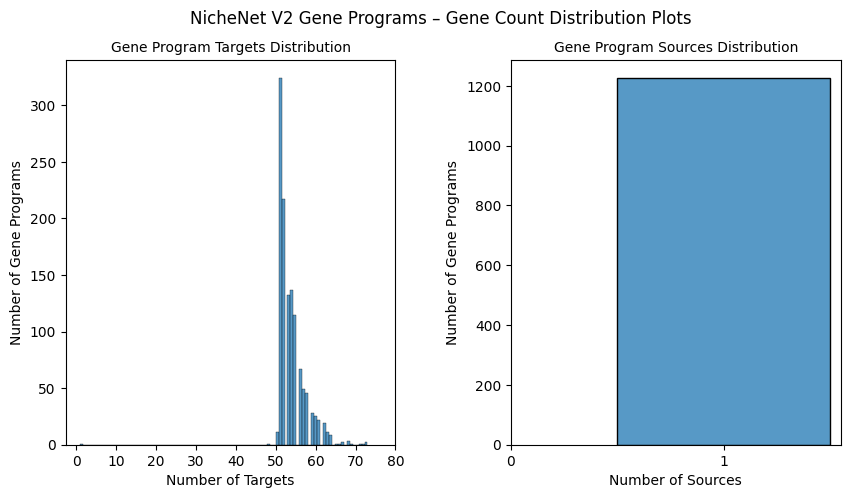

--- INITIALIZING NEW NETWORK MODULE: VARIATIONAL GENE PROGRAM GRAPH AUTOENCODER ---
LOSS -> include_edge_recon_loss: True, include_gene_expr_recon_loss: True, rna_recon_loss: nb
NODE LABEL METHOD -> one-hop-norm
ACTIVE GP THRESHOLD RATIO -> 0.01
LOG VARIATIONAL -> True
ONE HOP GCN NORM RNA NODE LABEL AGGREGATOR
ENCODER -> n_input: 17332, n_cat_covariates_embed_input: 0, n_hidden: 1326, n_latent: 1226, n_addon_latent: 100, n_fc_layers: 1, n_layers: 1, conv_layer: gcnconv, n_attention_heads: 0, dropout_rate: 0.0, 
COSINE SIM GRAPH DECODER -> dropout_rate: 0.0
MASKED TARGET RNA DECODER -> n_prior_gp_input: 1226, n_addon_gp_input: 100, n_cat_covariates_embed_input: 0, n_output: 17332
MASKED SOURCE RNA DECODER -> n_prior_gp_input: 1226, n_addon_gp_input: 100, n_cat_covariates_embed_input: 0, n_output: 17332

--- INITIALIZING TRAINER ---
Number of training nodes: 2203
Number of validation nodes: 0
Number of training edges: 8784
Number of validation edges: 0
Edge batch size: 64
Node batch siz

In [4]:
# =========================================================
# Step3: NicheCompass 无监督拓扑学习与过聚类（作者教程参数对齐版，NaN稳健）
# 可直接在单元格运行
# =========================================================
import scipy.sparse as sp
import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt

print("=== Step 3: NicheCompass 构建物理联通图与微型生态位骨架（教程参数对齐版）===")

# 1) 基础过滤 + 矩阵清洗
sc.pp.filter_genes(adata, min_cells=10)
adata_model = adata.copy()

if "counts" in adata_model.layers:
    mat = adata_model.layers["counts"]
    if sp.issparse(mat):
        mat = mat.copy()
        mat.data = np.nan_to_num(mat.data, nan=0.0, posinf=0.0, neginf=0.0)
        mat.data = np.clip(mat.data, a_min=0, a_max=None)
        adata_model.layers["counts"] = mat
    else:
        mat = np.nan_to_num(mat, nan=0.0, posinf=0.0, neginf=0.0)
        adata_model.layers["counts"] = np.clip(mat, a_min=0, a_max=None)

# 2) 不再筛选2000个高变基因（已移除），使用所有通过 min_cells=10 过滤的基因。

# 2.1) 关键修复：去掉总计数为0的spot，避免log(0) -> inf -> NaN
counts_key = "counts" if "counts" in adata_model.layers else None
x_for_lib = adata_model.layers[counts_key] if counts_key is not None else adata_model.X
lib_size = np.asarray(x_for_lib.sum(axis=1)).reshape(-1)
valid_spot_mask = np.isfinite(lib_size) & (lib_size > 0)
adata_model = adata_model[valid_spot_mask].copy()
print(f"✅ 保留 {adata_model.n_obs} 个有效spots（已移除总计数为0/非有限spots）")

# 再清洗一次，确保无NaN/Inf
if counts_key is not None:
    mat = adata_model.layers[counts_key]
    if sp.issparse(mat):
        mat = mat.copy()
        mat.data = np.nan_to_num(mat.data, nan=0.0, posinf=0.0, neginf=0.0)
        mat.data = np.clip(mat.data, a_min=0, a_max=None)
        adata_model.layers[counts_key] = mat
    else:
        mat = np.nan_to_num(mat, nan=0.0, posinf=0.0, neginf=0.0)
        adata_model.layers[counts_key] = np.clip(mat, a_min=0, a_max=None)

# 3) 空间图 + LR先验
sq.gr.spatial_neighbors(adata_model, coord_type="generic", spatial_key="spatial", n_neighs=8)
cache_dir = "/home/zhangjunyi/xiangmu/nichecompass-main/cache_nichenet"
gp_dict = nc.utils.extract_gp_dict_from_nichenet_lrt_interactions(
    species="human", version="v2",
    keep_target_genes_ratio=0.25, max_n_target_genes_per_gp=50,
    load_from_disk=True,
    lr_network_file_path=f"{cache_dir}/nichenet_lr_network.csv",
    ligand_target_matrix_file_path=f"{cache_dir}/nichenet_ligand_target_matrix.csv"
)
nc.utils.add_gps_from_gp_dict_to_adata(gp_dict=gp_dict, adata=adata_model)

# 4) 参照官方教程的 key/参数
adj_key = "spatial_connectivities"
gp_names_key = "nichecompass_gp_names"
active_gp_names_key = "nichecompass_active_gp_names"
gp_targets_mask_key = "nichecompass_gp_targets"
gp_targets_categories_mask_key = "nichecompass_gp_targets_categories"
gp_sources_mask_key = "nichecompass_gp_sources"
gp_sources_categories_mask_key = "nichecompass_gp_sources_categories"
latent_key = "nichecompass_latent"
conv_layer_encoder = "gcnconv"
active_gp_thresh_ratio = 0.01

# 训练参数（稳健版：降低NaN风险）
n_epochs = 50
n_epochs_all_gps = 10
lr = 1e-4
lambda_edge_recon = 1e5
lambda_gene_expr_recon = 100.0
lambda_l1_masked = 0.0
edge_batch_size = 64
node_batch_size = 128
n_sampled_neighbors = 4

# 5) Initialize + Train
model = nc.models.NicheCompass(
    adata_model,
    counts_key=counts_key,
    adj_key=adj_key,
    gp_names_key=gp_names_key,
    active_gp_names_key=active_gp_names_key,
    gp_targets_mask_key=gp_targets_mask_key,
    gp_targets_categories_mask_key=gp_targets_categories_mask_key,
    gp_sources_mask_key=gp_sources_mask_key,
    gp_sources_categories_mask_key=gp_sources_categories_mask_key,
    latent_key=latent_key,
    conv_layer_encoder=conv_layer_encoder,
    active_gp_thresh_ratio=active_gp_thresh_ratio,
)

model.train(
    n_epochs=n_epochs,
    n_epochs_all_gps=n_epochs_all_gps,
    lr=lr,
    lambda_edge_recon=lambda_edge_recon,
    lambda_gene_expr_recon=lambda_gene_expr_recon,
    lambda_l1_masked=lambda_l1_masked,
    edge_batch_size=edge_batch_size,
    node_batch_size=node_batch_size,
    n_sampled_neighbors=n_sampled_neighbors,
    edge_val_ratio=0.0,   # 避免验证阶段NaN指标中断训练
    node_val_ratio=0.0,
    use_cuda_if_available=True,
    verbose=False,
)

# =========================================================
# 保存结果 (AnnData + 模型)
# =========================================================
import os

# -------------------------- 1. 设置保存路径 --------------------------
save_base_dir = "/home/zhangjunyi/xiangmu/nichecompass-main/TuMeNiche/src/my/test_260325"
file_prefix = "test_260325_03"

# 确保目录存在，不存在则自动创建
os.makedirs(save_base_dir, exist_ok=True)

# -------------------------- 2. 保存 AnnData 对象 --------------------------
# 包含了原始数据、空间坐标、训练好的 latent embedding (nichecompass_latent) 等
adata_save_path = os.path.join(save_base_dir, f"{file_prefix}.h5ad")
adata_model.write_h5ad(adata_save_path)
print(f"✅ [1/2] AnnData 结果已保存至: {adata_save_path}")
# -------------------------- 3. 保存 NicheCompass 模型 --------------------------
# 保存模型权重和参数，方便后续直接 load 使用
model_save_dir = os.path.join(save_base_dir, f"{file_prefix}_model")
model.save(model_save_dir)
print(f"✅ [2/2] NicheCompass 模型已保存至: {model_save_dir}")

print("\n=== Step 3 & 4 全部完成 ===")


✅ [1/2] AnnData 已从 /home/zhangjunyi/xiangmu/nichecompass-main/TuMeNiche/src/my/test_260325/test_260325_03.h5ad 加载
--- INITIALIZING NEW NETWORK MODULE: VARIATIONAL GENE PROGRAM GRAPH AUTOENCODER ---
LOSS -> include_edge_recon_loss: True, include_gene_expr_recon_loss: True, rna_recon_loss: nb
NODE LABEL METHOD -> one-hop-norm
ACTIVE GP THRESHOLD RATIO -> 0.01
LOG VARIATIONAL -> True
ONE HOP GCN NORM RNA NODE LABEL AGGREGATOR
ENCODER -> n_input: 17332, n_cat_covariates_embed_input: 0, n_hidden: 1326, n_latent: 1226, n_addon_latent: 100, n_fc_layers: 1, n_layers: 1, conv_layer: gcnconv, n_attention_heads: 0, dropout_rate: 0.0, 
COSINE SIM GRAPH DECODER -> dropout_rate: 0.0
MASKED TARGET RNA DECODER -> n_prior_gp_input: 1226, n_addon_gp_input: 100, n_cat_covariates_embed_input: 0, n_output: 17332
MASKED SOURCE RNA DECODER -> n_prior_gp_input: 1226, n_addon_gp_input: 100, n_cat_covariates_embed_input: 0, n_output: 17332
✅ [2/2] NicheCompass 模型已从 /home/zhangjunyi/xiangmu/nichecompass-main/TuM

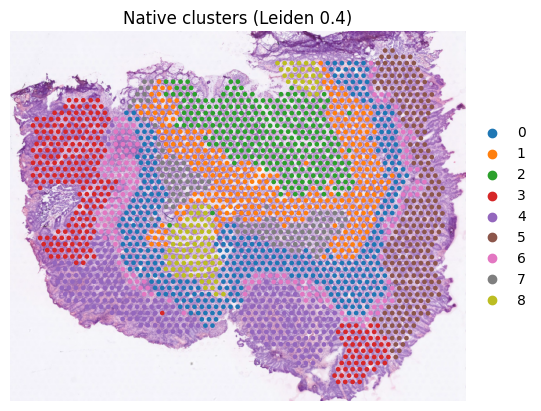

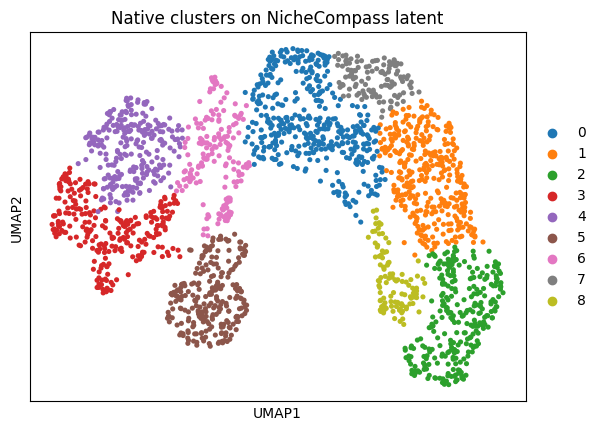

In [7]:
# =========================================================
# 前置步骤：加载 Step3 保存的结果 (AnnData + 模型)
# =========================================================
import os
import scanpy as sc
# 假设 nichecompass 已正确导入为 nc
import nichecompass as nc 

# -------------------------- 1. 定义加载路径 (与保存路径完全一致) --------------------------
save_base_dir = "/home/zhangjunyi/xiangmu/nichecompass-main/TuMeNiche/src/my/test_260325"
file_prefix = "test_260325_03"

# -------------------------- 2. 加载 AnnData 对象 --------------------------
adata_load_path = os.path.join(save_base_dir, f"{file_prefix}.h5ad")
adata_model = sc.read_h5ad(adata_load_path)
print(f"✅ [1/2] AnnData 已从 {adata_load_path} 加载")

# -------------------------- 3. 加载 NicheCompass 模型 --------------------------
model_load_dir = os.path.join(save_base_dir, f"{file_prefix}_model")
# 注意：load 函数需要传入对应的 adata_model 以恢复图结构等信息
model = nc.models.NicheCompass.load(
    dir_path=model_load_dir,
    adata=adata_model
)
print(f"✅ [2/2] NicheCompass 模型已从 {model_load_dir} 加载")

# -------------------------- 4. 恢复/定义关键参数变量 (供后续代码使用) --------------------------
# 这些变量名必须与你训练时的代码保持一致
latent_key = "nichecompass_latent"

# ✅ 修复：动态检查 counts_key，不要硬编码
if "counts" in adata_model.layers:
    counts_key = "counts"
else:
    counts_key = None  # 如果 layers 里没有 counts，就设为 None (使用 .X)
    print("⚠️ 警告: 在 layers 中未找到 'counts'，将默认使用 adata_model.X")

adj_key = "spatial_connectivities"
node_batch_size = 128  # 与训练时保持一致

print("✅ 关键参数变量已恢复，可继续运行后续代码")


# =========================================================
# Step3: 训练后仅查看 NicheCompass 原生聚类结果（无二次划分）
# 直接接在 model.train(...) 后运行
# =========================================================

# 1) 提取 latent（与训练保持同一 counts_key / adj_key）
adata_model.obsm[latent_key] = model.get_latent_representation(
    adata=adata_model,
    counts_key=counts_key,
    adj_key=adj_key,
    node_batch_size=node_batch_size,
)

# 2) 官方教程风格：latent 上建图 + UMAP
sc.pp.neighbors(adata_model, use_rep=latent_key, key_added=latent_key)
sc.tl.umap(adata_model, neighbors_key=latent_key)

# 3) 原生聚类（不过度切碎）
native_cluster_key = "latent_leiden_0.4"
sc.tl.leiden(
    adata_model,
    neighbors_key=latent_key,
    key_added=native_cluster_key,
    resolution=0.4
)

print(f"✅ 原生聚类完成：{adata_model.obs[native_cluster_key].nunique()} 类")

# 4) 仅可视化原生聚类（空间 + UMAP）
sc.pl.spatial(
    adata_model,
    color=native_cluster_key,
    # spot_size=170,
    size=1,
    title="Native clusters (Leiden 0.4)",
    frameon=False
)
sc.pl.umap(
    adata_model,
    color=native_cluster_key,
    title="Native clusters on NicheCompass latent"
)

阶段二：数据驱动的自适应阈值与代谢投影 (Data-Driven Projection)
step4——step5
先通过 NicheCompass 基于空间坐标构建组织的物理联通图，无监督学习生成微生态位基础骨架，锁定每个测序 spot 的真实空间邻居关系；
为每条代谢通讯轴计算空间耦合分数，结合 spot 自身的代谢发送能力与周边邻居的接收能力，量化真实的空间通讯潜力；
用高斯混合模型（GMM）为每条轴独立自适应设定活性阈值，分位数法兜底，再基于阈值完成微生态位的精准分型，对过渡区做后续空间拓扑优化；
最终通过分布可视化与空间置换检验，验证结果的生物学真实性与统计稳健性，排除随机噪音干扰。

=== 阶段二: 数据驱动的自适应阈值与代谢生态位初筛 ===
--> 1. 计算空间加权代谢通讯分数 (Coupling Score)...
--> 2. 学习每条代谢轴的自适应阈值 (GMM / Quantile)...


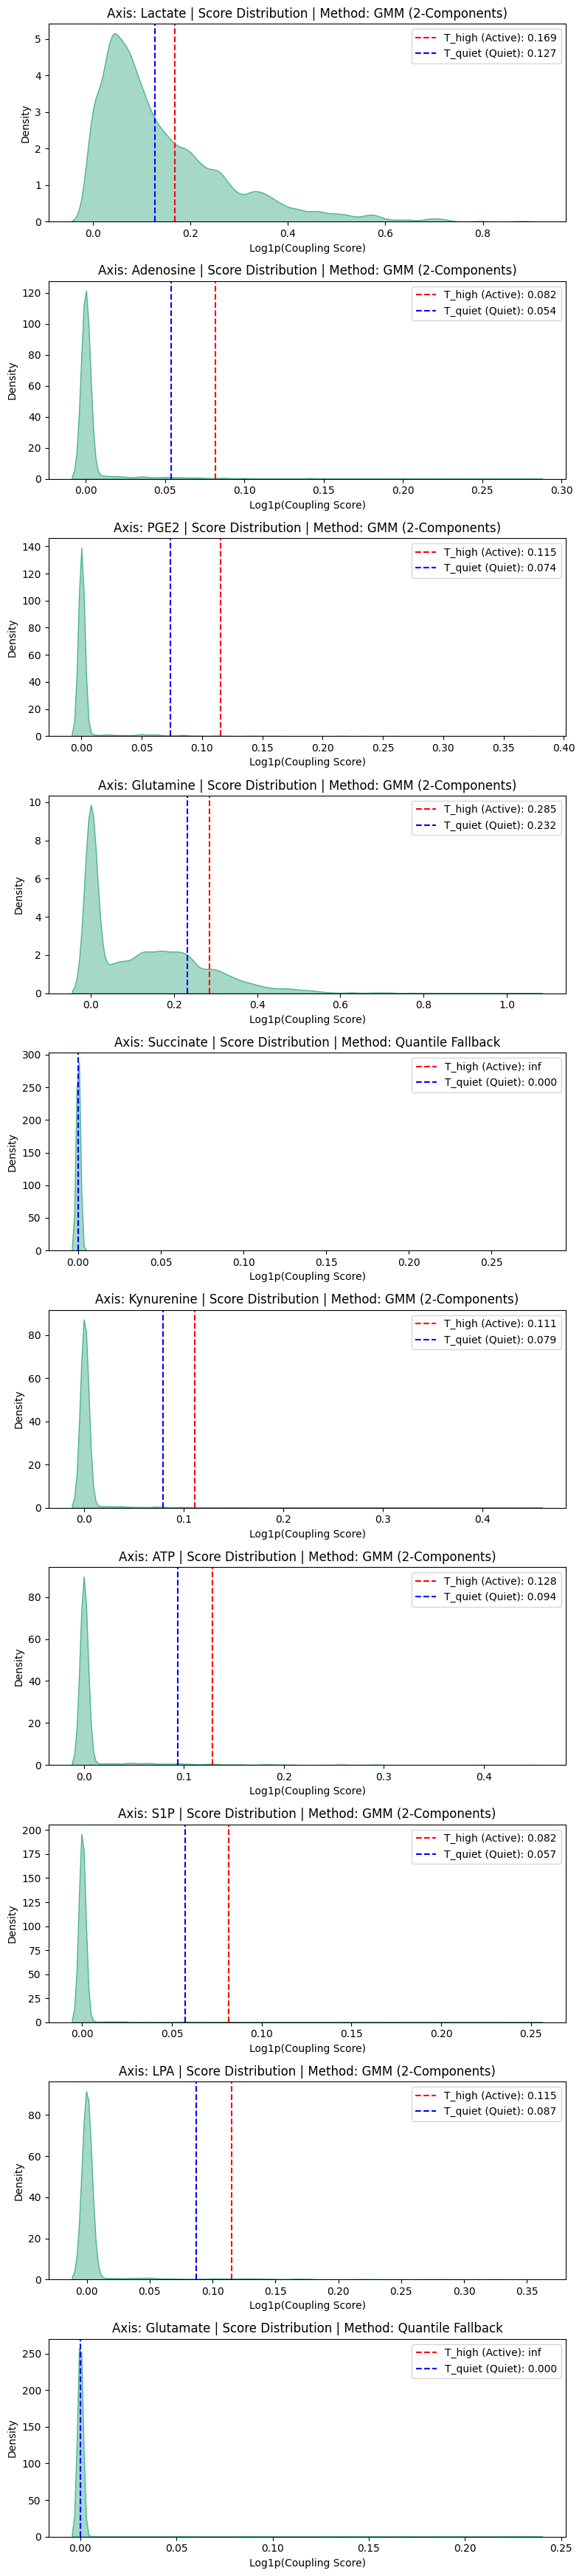


--- 自适应阈值计算结果 ---


,T_high,T_quiet,Method
Lactate,0.16859,0.127313,GMM (2-Components)
Adenosine,0.081596,0.053894,GMM (2-Components)
PGE2,0.11522,0.073678,GMM (2-Components)
Glutamine,0.285474,0.232283,GMM (2-Components)
Succinate,inf,0.0,Quantile Fallback
Kynurenine,0.111222,0.079173,GMM (2-Components)
ATP,0.128308,0.094259,GMM (2-Components)
S1P,0.08173,0.05716,GMM (2-Components)
LPA,0.115262,0.086804,GMM (2-Components)
Glutamate,inf,0.0,Quantile Fallback



--> 3. 统计微生态位特征，执行生物学标签映射 (全新容错与竞争逻辑)...

--- 微型生态位统计与标签判定表 ---


,Spot_Count,Initial_Label,Lactate_Active%,Adenosine_Active%,PGE2_Active%,Glutamine_Active%,Succinate_Active%,Kynurenine_Active%,ATP_Active%,S1P_Active%,LPA_Active%,Glutamate_Active%
Cluster_ID,,,,,,,,,,,,
0,410,Quiescent (Background),12.7,3.2,0.2,8.8,0.0,2.7,1.0,1.0,3.7,0.0
1,349,Quiescent (Background),4.3,1.1,1.7,9.7,0.0,0.9,4.9,0.3,4.6,0.0
2,284,Quiescent (Background),18.7,1.8,2.5,14.1,0.0,1.4,4.2,0.0,3.9,0.0
3,260,Single-axis: Lactate,63.1,3.5,0.0,15.8,0.0,4.6,1.2,2.7,0.4,0.0
4,253,Single-axis: Lactate,50.2,5.9,2.0,18.6,0.0,2.4,2.0,2.8,1.2,0.0
5,247,Single-axis: Lactate,89.1,3.6,0.0,28.3,0.0,5.3,1.6,1.6,0.0,0.0
6,173,Quiescent (Background),28.3,1.7,0.6,11.6,0.0,2.9,2.9,1.7,5.8,0.0
7,119,Quiescent (Background),0.0,0.0,0.8,2.5,0.0,0.0,1.7,0.8,7.6,0.0
8,108,Quiescent (Background),25.0,5.6,2.8,23.1,0.0,1.9,1.9,1.9,5.6,0.0



--> 4. 绘制初步判定的微环境空间地图...


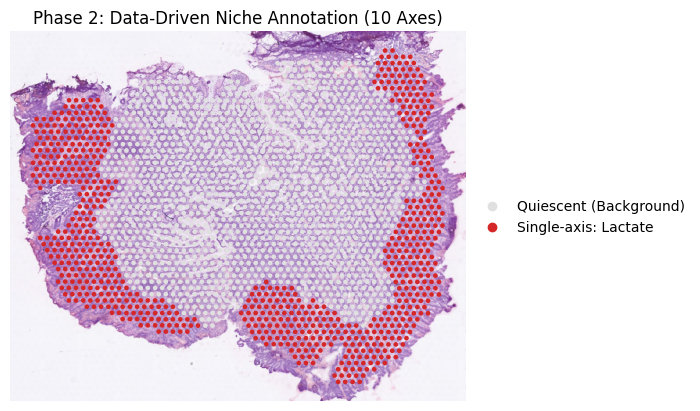

✅ 阶段二执行完毕！已定位出单轴区、多轴区、休眠区及待重塑的 Transitional 灰度区。


In [8]:
# =========================================================
# Cell 4: 空间通讯加权分数计算与生态位标注 (阶段二)
# =========================================================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc
from sklearn.mixture import GaussianMixture
from IPython.display import display

print("=== 阶段二: 数据驱动的自适应阈值与代谢生态位初筛 ===")

# ---------------------------------------------------------
# Step 4.1: 构建空间感知的连续通讯分数 (Coupling Score)
# ---------------------------------------------------------
print("--> 1. 计算空间加权代谢通讯分数 (Coupling Score)...")
# 获取基于 squidpy 生成的空间物理邻接矩阵
adj_matrix = adata_model.obsp["spatial_connectivities"]

for k in AXES:
    sender_scores = adata_model.obs[f"{k}_Sender_Score"].values
    receiver_scores = adata_model.obs[f"{k}_Receiver_Score"].values
    
    # 核心公式: 自身 Sender * 周围所有物理邻居的 Receiver 之和
    neighbor_receiver_sum = adj_matrix.dot(receiver_scores)
    raw_coupling = sender_scores * neighbor_receiver_sum
    
    # 为了后续更好拟合高斯分布，对存在严重长尾的连乘分数进行 log1p 转换
    coupling_score = np.log1p(raw_coupling)
    adata_model.obs[f"Coupling_{k}"] = coupling_score

# ---------------------------------------------------------
# Step 4.2: 自适应混合阈值算法 (GMM + Quantile 兜底)
# ---------------------------------------------------------
print("--> 2. 学习每条代谢轴的自适应阈值 (GMM / Quantile)...")
thresholds_dict = {}

# 准备画图，将阈值切分可视化 (非常适合放入论文 Supplementary)
fig, axes = plt.subplots(len(AXES), 1, figsize=(8, 3.5 * len(AXES)))
if len(AXES) == 1: axes =[axes]

for idx, k in enumerate(AXES):
    scores = adata_model.obs[f"Coupling_{k}"].values
    
    # 提取非零有效值用于拟合 (去除纯背景底噪点的影响)
    scores_clean = scores[~np.isnan(scores) & (scores > 0)].reshape(-1, 1)
    
    t_high, t_quiet = None, None
    method_used = "Quantile Fallback"
    
    # -- 优先尝试 2-Component GMM --
    if len(scores_clean) > 50:  # 只有当非零点足够多才跑 GMM
        try:
            gmm = GaussianMixture(n_components=2, random_state=42)
            labels = gmm.fit_predict(scores_clean)
            
            m0, m1 = gmm.means_[0][0], gmm.means_[1][0]
            s0, s1 = np.sqrt(gmm.covariances_[0][0][0]), np.sqrt(gmm.covariances_[1][0][0])
            
            # 校验: 两个峰要有显著区分度 (均值差 > 1倍全局标准差)
            if abs(m0 - m1) > np.std(scores_clean):
                if m0 > m1:
                    t_high = np.min(scores_clean[labels == 0]) # 信号峰最小值
                    t_quiet = m1 + s1                          # 背景峰均值+1SD
                else:
                    t_high = np.min(scores_clean[labels == 1])
                    t_quiet = m0 + s0
                method_used = "GMM (2-Components)"
        except Exception as e:
            pass # 如果GMM不收敛或抛错，平滑过渡到底部分位数策略
            
    # -- 兜底策略: 分位数法 (q85 & q35) --
    if t_high is None:
        t_high = np.quantile(scores, 0.85)
        t_quiet = np.quantile(scores, 0.35)
    
    # 硬基线安全锁: 如果阈值算出来太低，说明全组织都没活化
    if t_high < 0.05:
        t_high = np.inf
        
    thresholds_dict[k] = {'T_high': t_high, 'T_quiet': t_quiet, 'Method': method_used}
    
    # 将 Spot 状态记录回 obs
    adata_model.obs[f"Active_{k}"] = (scores >= t_high).astype(int)
    adata_model.obs[f"Quiet_{k}"] = (scores <= t_quiet).astype(int)
    
    # 画密度分布及阈值线
    sns.kdeplot(scores, ax=axes[idx], fill=True, color="#4CB391", alpha=0.5, bw_adjust=0.5)
    axes[idx].axvline(t_high, color='red', linestyle='--', label=f'T_high (Active): {t_high:.3f}')
    axes[idx].axvline(t_quiet, color='blue', linestyle='--', label=f'T_quiet (Quiet): {t_quiet:.3f}')
    axes[idx].set_title(f"Axis: {k} | Score Distribution | Method: {method_used}")
    axes[idx].set_xlabel("Log1p(Coupling Score)")
    axes[idx].legend()

plt.tight_layout()
plt.show()

# 打印阈值结果表
df_thresholds = pd.DataFrame(thresholds_dict).T
print("\n--- 自适应阈值计算结果 ---")
display(df_thresholds)


# ---------------------------------------------------------
# Step 5: 微型生态位 (Micro-clusters) 统计判定与初标注
# ---------------------------------------------------------
print("\n--> 3. 统计微生态位特征，执行生物学标签映射 (全新容错与竞争逻辑)...")

cluster_annotations = {}
cluster_stats =[]
native_clusters = adata_model.obs[native_cluster_key].unique()

for c in sorted(native_clusters):
    c_mask = adata_model.obs[native_cluster_key] == c
    total_spots = c_mask.sum()
    
    active_fracs = {}
    quiet_fracs = {}
    
    # 统计本 cluster 在各条轴上的分布比例
    for k in AXES:
        active_fracs[k] = adata_model.obs.loc[c_mask, f"Active_{k}"].sum() / total_spots
        quiet_fracs[k] = adata_model.obs.loc[c_mask, f"Quiet_{k}"].sum() / total_spots
        
    # --- 全新判定逻辑应用 ---
    # 1. 提取所有活跃比例 > 30% 的轴
    active_axes =[k for k, v in active_fracs.items() if v > 0.30]
    
    # 2. 判定 Quiescent 休眠生态位 (引入容错率)
    avg_quiet = np.mean(list(quiet_fracs.values()))
    max_active = np.max(list(active_fracs.values()))
    
    # 容错条件A: 平均休眠率 > 60% 且 没有任何轴活跃率超过 20%
    cond_a_quiescent = (avg_quiet > 0.60) and (max_active <= 0.20)
    # 容错条件B: 至少 8 条轴满足休眠率 > 60% 且 活跃率 < 15%
    count_dead_axes = sum(1 for k in AXES if quiet_fracs[k] > 0.60 and active_fracs[k] < 0.15)
    cond_b_quiescent = count_dead_axes >= 8
    
    is_quiescent = cond_a_quiescent or cond_b_quiescent
    
    # 3. 执行严格互斥判定
    if len(active_axes) == 1:
        # 只要走到这一步，必定有一条轴 > 30%，且其他所有轴天然 < 30% (否则长度就 >= 2 了)
        c_label = f"Single-axis: {active_axes[0]}"
    elif len(active_axes) >= 2:
        # 同时有两条及以上的轴突破 30% 绝对主导线
        c_label = f"Multi-axis: {', '.join(active_axes)}"
    elif is_quiescent:
        c_label = "Quiescent (Background)"
    else:
        # 所有轴都 < 30%，且又不符合背景休眠条件（如：混杂了各种 10%~29% 的弱信号）
        c_label = "Transitional"
        
    cluster_annotations[c] = c_label
    
    # 保存统计数据用于查看
    stat_row = {'Cluster_ID': c, 'Spot_Count': total_spots, 'Initial_Label': c_label}
    for k in AXES: stat_row[f"{k}_Active%"] = round(active_fracs[k] * 100, 1)
    cluster_stats.append(stat_row)

# 将判定映射回 adata_model (供下一阶段拆分合并使用)
adata_model.obs["Niche_Annotation"] = adata_model.obs[native_cluster_key].map(cluster_annotations)

# 打印微环境判定报表
df_cluster_stats = pd.DataFrame(cluster_stats).set_index('Cluster_ID')
print("\n--- 微型生态位统计与标签判定表 ---")
display(df_cluster_stats)

# ---------------------------------------------------------
# 可视化: 初判后的空间生态位地图
# ---------------------------------------------------------
print("\n--> 4. 绘制初步判定的微环境空间地图...")

# ==============================
# 1. 扩充为 20 种高对比度离散颜色 (Tab20 经典色板)
# 足够应对 10 轴带来的十几种生态位类别
# ==============================
color_list =[
    "#d62728", "#1f77b4", "#2ca02c", "#ff7f0e", "#9467bd", 
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
    "#ff9896", "#aec7e8", "#98df8a", "#ffbb78", "#c5b0d5", 
    "#c49c94", "#f7b6d2", "#c7c7c7", "#dbdb8d", "#9edae5"
]

# ==============================
# 2. 获取数据里的实际类别，并按顺序分配颜色
# ==============================
all_categories = adata_model.obs["Niche_Annotation"].unique().tolist()

# 强制将 Quiescent 和 Transitional 固定为不显眼的底色，让活跃轴更突出
custom_palette = {}
color_idx = 0

for cat in all_categories:
    if "Quiescent" in cat:
        custom_palette[cat] = "#e0e0e0"  # 浅灰色代表无代谢底噪
    elif "Transitional" in cat:
        custom_palette[cat] = "#ffe119"  # 亮黄色代表过渡交界区
    else:
        # 分配大色板中的颜色
        custom_palette[cat] = color_list[color_idx % len(color_list)]
        color_idx += 1

# ==============================
# 3. 画图
# ==============================
sc.pl.spatial(
    adata_model,
    color="Niche_Annotation",
    size=1, # 保持你修改后的 size=1 
    title="Phase 2: Data-Driven Niche Annotation (10 Axes)",
    frameon=False,
    palette=custom_palette
)
print("✅ 阶段二执行完毕！已定位出单轴区、多轴区、休眠区及待重塑的 Transitional 灰度区。")

查看各个代谢轴的浓度梯度图

=== 附加分析: 生成十种代谢物空间通讯浓度梯度图 ===
注: 采用 Coupling_Score (Sender * 邻居Receiver) 作为有效代谢物浓度与作用场的推断指标


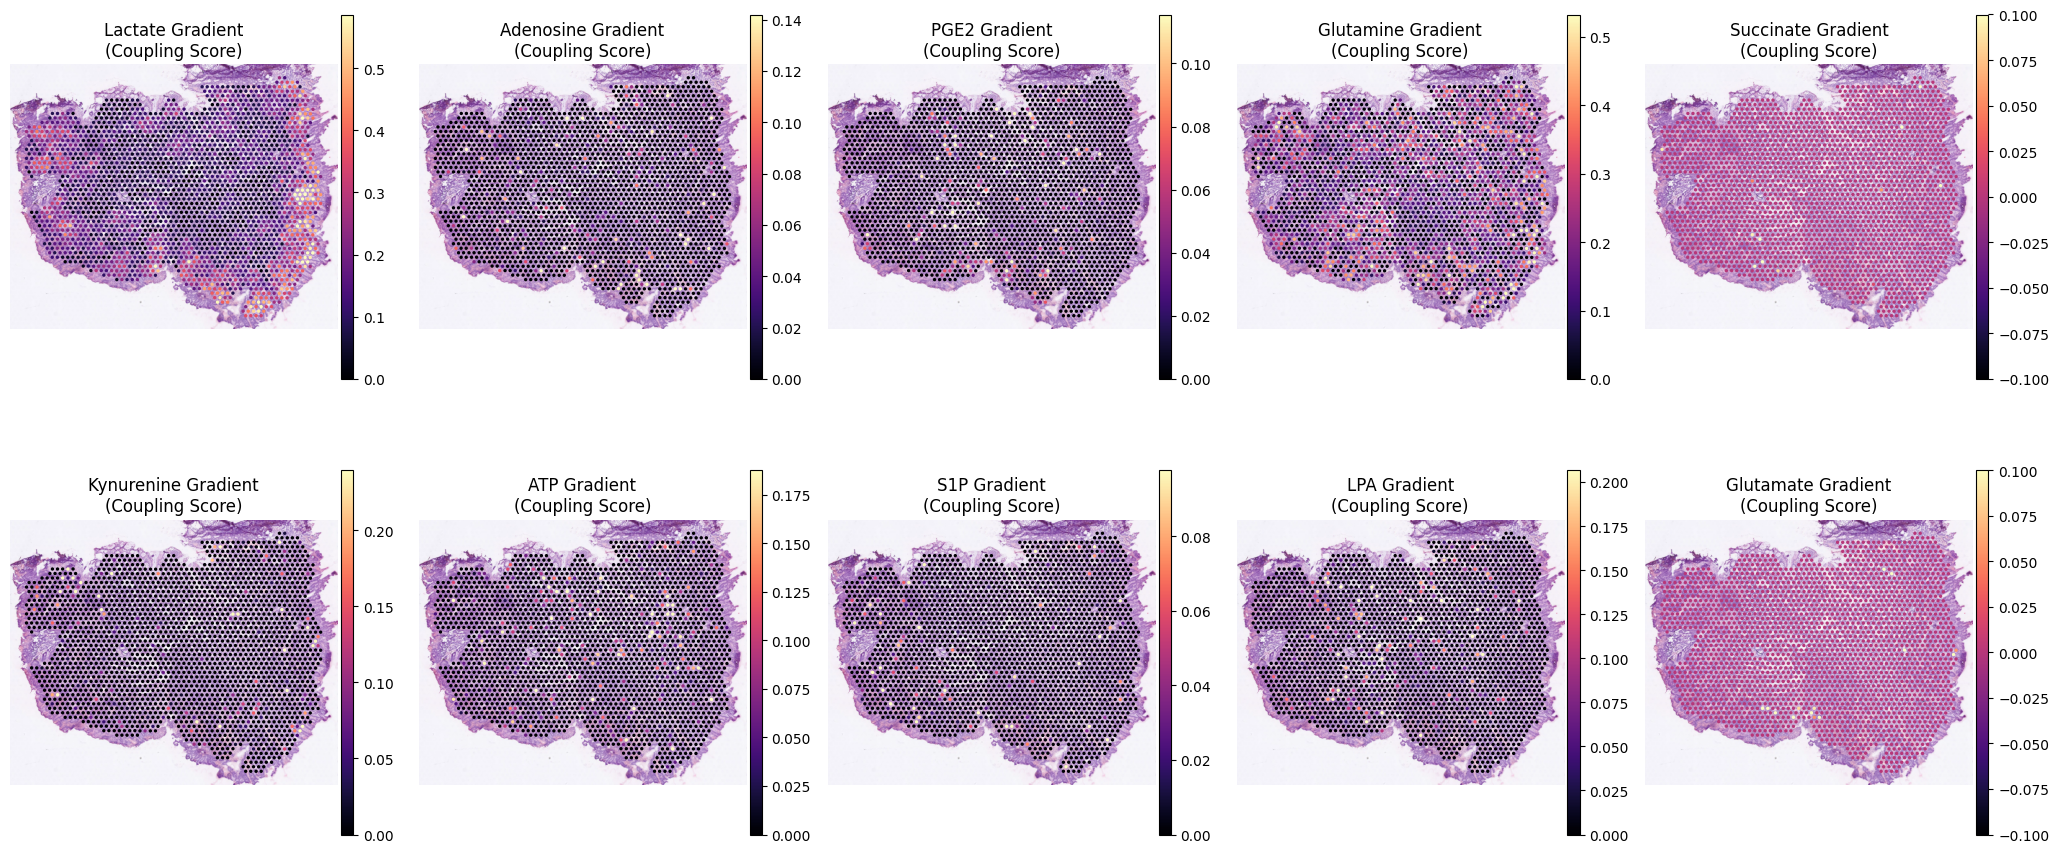

✅ 10 种代谢物的浓度梯度图绘制完毕！


In [12]:
# =========================================================
# Cell 5: 绘制 10 种代谢物的空间浓度梯度图 (连续分布)
# =========================================================
import matplotlib.pyplot as plt
import scanpy as sc

print("=== 附加分析: 生成十种代谢物空间通讯浓度梯度图 ===")
print("注: 采用 Coupling_Score (Sender * 邻居Receiver) 作为有效代谢物浓度与作用场的推断指标")

# 1. 获取需要绘制的列名 (Coupling_Score 已经在上一步取了 log1p，非常适合梯度可视化)
gradient_columns = [f"Coupling_{k}" for k in AXES]

# 2. 为每张图设置好标题
plot_titles =[f"{k} Gradient\n(Coupling Score)" for k in AXES]

# 3. 设置绘图参数
# 使用 'magma' 或 'inferno' 色系，这种暗底亮色的色谱非常适合展示类似“荧光染色”的浓度梯度
cmap_choice = "magma" 

# 4. 利用 scanpy 自带的多图排列功能绘制
sc.pl.spatial(
    adata_model,
    color=gradient_columns,
    cmap=cmap_choice,
    size=1,              # 保持与你前面一致的 spot 大小
    ncols=5,             # 每行放 5 张图，10 个轴正好 2 行
    frameon=False,       # 去掉坐标轴边框，更美观
    title=plot_titles,
    vmin=0,              # 浓度最低为 0
    vmax='p99',          # 截断最高 1% 的极端离群值，让主体梯度颜色更丰富
    show=False           # 先不显示，稍后通过 plt.show() 统一控制
)

# 调整子图间距并展示
plt.subplots_adjust(wspace=0.1, hspace=0.2)
fig = plt.gcf()
fig.set_size_inches(25, 10) # 设置大画布，保证高分辨率
plt.show()

print("✅ 10 种代谢物的浓度梯度图绘制完毕！")

阶段三  空间拓扑图剪枝与重塑 (Spatial Refinement: Split, Merge & Smooth)

=== 阶段三: 空间拓扑图剪枝与重塑 (Split, Merge & Smooth) ===
--> 1. Split (破): 正在探索 Transitional 过渡区内的高代谢连通子图...
    [Split] 成功从过渡区中抢救裂变出 0 个具有空间连通性的活跃 Spots。
--> 2. Merge (立): 正在跨物理空间合并功能同型的生态位...
    [Merge] 当前合并后的宏观生态位类型: ['TMCN_Quiescent', 'TMCN_Lactate_Axis']
--> 3. Smooth (平滑): 强制注销极小碎片，并入邻接主力生态位...
    [Smooth] 扫描发现 0 个孤立噪音碎片 (面积 < 20)。
    [Smooth] 平滑去噪完成！所有连续性硬约束均满足。

--> 4. 绘制拓扑精修后的【最终代谢通讯生态位 (TMCN)】地图...


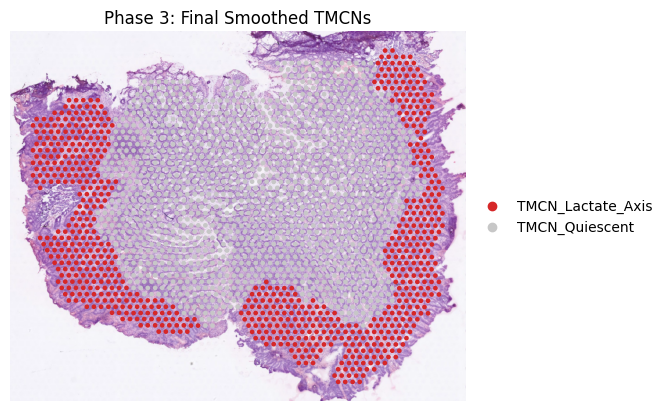

✅ 阶段三执行完毕！微型聚类已成功升维并重塑为宏观、空间连续的代谢通讯生态位。


In [13]:
# =========================================================
# Cell 5: 空间拓扑图剪枝与重塑 (阶段三: Split, Merge & Smooth)
# =========================================================
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scanpy as sc
import matplotlib.pyplot as plt

print("=== 阶段三: 空间拓扑图剪枝与重塑 (Split, Merge & Smooth) ===")

# 初始化工作列
adata_model.obs["Niche_Type"] = adata_model.obs["Niche_Annotation"].astype(str)
adj = adata_model.obsp["spatial_connectivities"]

# ---------------------------------------------------------
# Step 6: Split（破）—— 图连通优先的异质区拆解
# ---------------------------------------------------------
print("--> 1. Split (破): 正在探索 Transitional 过渡区内的高代谢连通子图...")
min_cc_size = 20  # 连通子图的最小 spot 面积阈值
transitional_mask = (adata_model.obs["Niche_Type"] == "Transitional").values

# 6.1: 首先探查 Transitional 区域内每一个 Spot 自己的 Active 状态
tentative_labels = np.array([""] * adata_model.n_obs, dtype=object)
for i in range(adata_model.n_obs):
    if transitional_mask[i]:
        active_axes = [k for k in AXES if adata_model.obs[f"Active_{k}"].iloc[i] == 1]
        if len(active_axes) == 1:
            tentative_labels[i] = f"Single-axis: {active_axes[0]}"
        elif len(active_axes) > 1:
            tentative_labels[i] = "Multi-axis: Mixed"
        else:
            tentative_labels[i] = "Transitional"

# 6.2: 利用空间物理连通图，寻找大面积的活跃斑块
split_count = 0
for label in np.unique(tentative_labels):
    if not label or label == "Transitional":
        continue
        
    # 获取属于该潜在标签的 spots 索引
    label_indices = np.where((tentative_labels == label) & transitional_mask)[0]
    if len(label_indices) == 0: continue
        
    # 提取物理图的子图 (Subgraph)
    sub_adj = adj[label_indices, :][:, label_indices]
    
    # 求解最大连通子图 (Connected Components)
    n_components, labels = sp.csgraph.connected_components(sub_adj, directed=False)
    counts = np.bincount(labels)
    valid_components = np.where(counts >= min_cc_size)[0]
    
    # 达到面积阈值的，将其从 Transitional 裂变为正式生态位
    for comp in valid_components:
        comp_indices = label_indices[labels == comp]
        adata_model.obs.iloc[comp_indices, adata_model.obs.columns.get_loc("Niche_Type")] = label
        split_count += len(comp_indices)

print(f"    [Split] 成功从过渡区中抢救裂变出 {split_count} 个具有空间连通性的活跃 Spots。")


# ---------------------------------------------------------
# Step 7: Merge（立）—— 功能同型合并为宏观生态位
# ---------------------------------------------------------
print("--> 2. Merge (立): 正在跨物理空间合并功能同型的生态位...")
def map_niche_name(raw_name):
    if raw_name.startswith("Single-axis:"):
        axis = raw_name.split(": ")[1]
        return f"TMCN_{axis}_Axis"
    elif raw_name.startswith("Multi-axis"):
        return "TMCN_Mixed_Axis"
    elif raw_name.startswith("Quiescent"):
        return "TMCN_Quiescent"
    else:
        return "TMCN_Transitional"

adata_model.obs["Niche_Type"] = adata_model.obs["Niche_Type"].apply(map_niche_name)
print(f"    [Merge] 当前合并后的宏观生态位类型: {adata_model.obs['Niche_Type'].unique().tolist()}")


# ---------------------------------------------------------
# Step 8: 空间连续性硬约束（平滑去噪 Smooth）
# ---------------------------------------------------------
print("--> 3. Smooth (平滑): 强制注销极小碎片，并入邻接主力生态位...")
min_area_smooth = max(20, int(adata_model.n_obs * 0.005)) # 至少20个点，或0.5%总面积
niche_types = adata_model.obs["Niche_Type"].unique()
noise_mask = np.zeros(adata_model.n_obs, dtype=bool)

# 8.1: 全局扫描寻找碎片
for nt in niche_types:
    indices = np.where(adata_model.obs["Niche_Type"] == nt)[0]
    if len(indices) == 0: continue
    
    sub_adj = adj[indices, :][:, indices]
    n_components, labels = sp.csgraph.connected_components(sub_adj, directed=False)
    counts = np.bincount(labels)
    
    # 找到所有太小的孤立岛屿
    small_comps = np.where(counts < min_area_smooth)[0]
    for comp in small_comps:
        comp_indices = indices[labels == comp]
        noise_mask[comp_indices] = True

print(f"    [Smooth] 扫描发现 {noise_mask.sum()} 个孤立噪音碎片 (面积 < {min_area_smooth})。")

# 8.2: 依据“最大接触边数”进行邻域传播平滑 (KNN Label Propagation)
adata_model.obs["Final_Niche_Type"] = adata_model.obs["Niche_Type"].astype(str)
adata_model.obs.loc[noise_mask, "Final_Niche_Type"] = "Noise"

max_iter = 10
for iteration in range(max_iter):
    current_noise = (adata_model.obs["Final_Niche_Type"] == "Noise").values
    if not current_noise.any():
        break
        
    noise_indices = np.where(current_noise)[0]
    new_labels =[]
    
    for idx in noise_indices:
        # 获取该 spot 的所有物理邻居
        neighbors = adj[idx].indices
        neighbor_labels = adata_model.obs["Final_Niche_Type"].iloc[neighbors]
        valid_labels = neighbor_labels[neighbor_labels != "Noise"]
        
        if len(valid_labels) > 0:
            # 多数投票：并入周围最大的生态位
            new_labels.append(valid_labels.mode()[0])
        else:
            new_labels.append("Noise")
            
    adata_model.obs.iloc[noise_indices, adata_model.obs.columns.get_loc("Final_Niche_Type")] = new_labels

# 兜底：如果还有全是 Noise 组成的孤岛没被吞并，强制标记为休眠或过渡态
leftover = (adata_model.obs["Final_Niche_Type"] == "Noise").values
if leftover.sum() > 0:
    adata_model.obs.loc[leftover, "Final_Niche_Type"] = "TMCN_Transitional"

print("    [Smooth] 平滑去噪完成！所有连续性硬约束均满足。")


# ---------------------------------------------------------
# 可视化: 阶段三重塑后的最终生态位 (Final Niche Type)
# ---------------------------------------------------------
print("\n--> 4. 绘制拓扑精修后的【最终代谢通讯生态位 (TMCN)】地图...")

# 构建专业、具有生物学直觉的颜色字典 (配色更符合Nature/Cell审美)
custom_palette = {
    # 原来 5 个
    "TMCN_Lactate_Axis": "#d62728",        # 红
    "TMCN_Adenosine_Axis": "#1f77b4",      # 蓝
    "TMCN_PGE2_Axis": "#ff7f0e",           # 橙
    "TMCN_Glutamine_Axis": "#2ca02c",      # 绿
    "TMCN_Succinate_Axis": "#9467bd",      # 紫

    # 新增 5 个（我已帮你配好顶刊配色）
    "TMCN_Kynurenine_Axis": "#e377c2",     # 粉紫
    "TMCN_ATP_Axis": "#17becf",            # 青
    "TMCN_S1P_Axis": "#7f7f7f",            # 深灰
    "TMCN_LPA_Axis": "#ff9896",            # 浅红
    "TMCN_Glutamate_Axis": "#fada5e",      # 金黄

    # 公共类型
    "TMCN_Mixed_Axis": "#8c564b",          # 棕色
    "TMCN_Quiescent": "#c7c7c7",           # 浅灰
    "TMCN_Transitional": "#bcbd22"         # 黄绿
}

# 提取当前存在的生态位，并筛选颜色
final_categories = adata_model.obs["Final_Niche_Type"].unique().tolist()
active_palette = {cat: custom_palette.get(cat, "#000000") for cat in final_categories}

sc.pl.spatial(
    adata_model,
    color="Final_Niche_Type",
    # spot_size=170,
    size=1,
    title="Phase 3: Final Smoothed TMCNs",
    frameon=False,
    palette=active_palette
)

print("✅ 阶段三执行完毕！微型聚类已成功升维并重塑为宏观、空间连续的代谢通讯生态位。")

计算5 个核心聚类评价指标（Homogeneity, Completeness, NMI, AMI, ARI）

In [14]:
# =========================================================
# Cell 6: 聚类指标定量评估 (Initial & Final vs 病理学金标准)
# =========================================================
import os
import pandas as pd
from sklearn.metrics import (
    homogeneity_score,
    completeness_score,
    normalized_mutual_info_score,
    adjusted_mutual_info_score,
    adjusted_rand_score
)

print("=== 附加分析: 计算聚类评估指标 (与病理学注释对比) ===")

# 1. 确保输出文件夹存在
out_dir = "/home/zhangjunyi/xiangmu/nichecompass-main/outputs/colorectal_12_cancer_CRC/test_260325_03"
os.makedirs(out_dir, exist_ok=True)

# 2. 检查并获取病理学标签
# 为了防止 adata_model 在之前的过滤(min_cells=10等)中丢失了 obs 的某些列，增加一步安全校验
if 'pathology_annotation' not in adata_model.obs.columns:
    print("⚠️ 提示: adata_model.obs 中未找到 'pathology_annotation'，正在从原始 adata 中同步...")
    if 'pathology_annotation' in adata.obs.columns:
        adata_model.obs['pathology_annotation'] = adata.obs['pathology_annotation']
    else:
        raise ValueError("❌ 原始 adata 中也没有找到 'pathology_annotation' 列，无法计算评价指标！")

# 3. 提取用于计算评价指标的列
# 'native_cluster_key' 为 Cell 3 中的初始 Leiden 聚类结果 (latent_leiden_0.4)
# 'Final_Niche_Type' 为 Cell 5 中的最终生态位结果
df_eval = adata_model.obs[['pathology_annotation', native_cluster_key, 'Final_Niche_Type']].copy()

# 4. 清洗数据（去除金标准为 NaN 或无效注释的 Spot）
# 病理学注释中有时会有无法判定的区域，计算时必须排除这部分
valid_mask = df_eval['pathology_annotation'].notna() & \
             (~df_eval['pathology_annotation'].astype(str).str.lower().isin(['nan', 'na', 'unknown', 'unassigned']))
df_eval_valid = df_eval[valid_mask]

print(f"--> 模型总 Spot 数: {len(df_eval)}")
print(f"--> 具有有效病理学注释的 Spot 数: {len(df_eval_valid)}")

# 提取 ground truth (真实标签) 和 predictions (预测标签)
y_true = df_eval_valid['pathology_annotation'].astype(str)
y_pred_initial = df_eval_valid[native_cluster_key].astype(str)
y_pred_final = df_eval_valid['Final_Niche_Type'].astype(str)

# 5. 定义指标计算函数
def calculate_metrics(y_t, y_p, method_name):
    return {
        "Method": method_name,
        "Homogeneity": homogeneity_score(y_t, y_p),
        "Completeness": completeness_score(y_t, y_p),
        "NMI": normalized_mutual_info_score(y_t, y_p),
        "AMI": adjusted_mutual_info_score(y_t, y_p),
        "ARI": adjusted_rand_score(y_t, y_p)
    }

# 6. 计算 Initial 结果 和 Final 结果的指标
metrics_initial = calculate_metrics(y_true, y_pred_initial, "Initial_NicheCompass (Leiden 0.4)")
metrics_final = calculate_metrics(y_true, y_pred_final, "Final_TMCN (Phase 3)")

# 7. 整理为 DataFrame 并打印展示
df_metrics = pd.DataFrame([metrics_initial, metrics_final])
print("\n--- 聚类性能评估结果 ---")
display(df_metrics)

# 8. 保存到指定文件夹
out_file = os.path.join(out_dir, "clustering_evaluation_metrics.csv")
df_metrics.to_csv(out_file, index=False)
print(f"\n✅ 评估指标计算完成！结果已成功保存至:\n {out_file}")

=== 附加分析: 计算聚类评估指标 (与病理学注释对比) ===
--> 模型总 Spot 数: 2203
--> 具有有效病理学注释的 Spot 数: 2203

--- 聚类性能评估结果 ---


,Method,Homogeneity,Completeness,NMI,AMI,ARI
0,Initial_NicheCompass (Leiden 0.4),0.352327,0.311181,0.330479,0.326094,0.173565
1,Final_TMCN (Phase 3),0.231833,0.673839,0.344978,0.344146,0.247373



✅ 评估指标计算完成！结果已成功保存至:
 /home/zhangjunyi/xiangmu/nichecompass-main/outputs/colorectal_12_cancer_CRC/test_260325_03/clustering_evaluation_metrics.csv
